# Model Training Script

This script trains machine learning models using historical and operational climate forecast datasets to predict hydrologic components and Net Basin Supply (NBS) across the Great Lakes basin.

## Training Data

Model inputs are derived from:

* **Climate Forecast System Reanalysis (CFSR)** data spanning **1979–2010**
* **Climate Forecast System Analysis (CFSA)** forecast data spanning **2011–2024**

## Target Variables

The machine learning models are trained to predict the following hydrologic components simultaneously across all five Great Lakes:

* Precipitation
* Evaporation
* Runoff
* Net Basin Supply (NBS)

Target datasets include:

* **L2SWBM** for precipitation, evaporation, and runoff
* **Great Lakes Coordinating Committee (GLCC)** datasets for NBS

## Modeling Framework

The workflow combines large-scale climate forecast predictors with observed hydrologic targets to train machine learning models capable of subseasonal-to-annual forecasting across the Great Lakes basin. Simultaneous multi-lake training preserves spatial and temporal relationships between lakes and hydrologic processes.


In [58]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import matplotlib.pyplot as plt
import sys
import re
import os
import copy

In [59]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader
from src.data_processor import SeasonalCycleProcessor


### Configure Input Paths and Optional Predictors

This cell defines the local repository and input data paths used throughout the workflow. Users should update `local_path` to match the location where the repository was cloned on their system.

Optional predictor datasets, including Great Lakes Surface Temperature (GLSEA SST) and Snow Water Equivalent (SWE), can be enabled or disabled using the `use_sst` and `use_swe` flags (True/False). Corresponding file paths are also specified for loading these datasets into the machine learning feature pipeline.


In [60]:
# ---- Input Paths ---- #

# Local directory where the repository was cloned.
# Update this path to match your local system.
local_path = '/Users/ljob/Desktop/'

# Input directory
input_dir = local_path + 'cnbs-predictor/data/'

# CFSR data
cfsr_file = input_dir + 'cfsr/CFSR_archived_1979-2024.csv'

# ---- Optional Predictor Variables ---- #

# Include Great Lakes Surface Temperature (GLSEA SST) predictors? 
# True/False
use_sst = False

# GLSEA SST input file (Kelvin)
sst_file = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Include Snow Water Equivalent (SWE) predictors?
# True/False
use_swe = False

# SWE input file
swe_file = input_dir + 'cfsr/CFSR_SWE_Basin_mm.csv'

## Begin Script

### Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

#### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

#### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

#### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

#### 4. Include Seasonality and Temporal Features
* Extract the calendar month from the datetime index.
* Encode seasonality using cyclic temporal features:

  * `month_sin`
  * `month_cos`

These cyclical variables preserve the continuous seasonal relationship between months (e.g., December transitions smoothly into January) and avoid artificial discontinuities introduced by one-hot encoding (i.e., month_1 = True).

* Include a continuous `time` feature representing long-term temporal progression to help smooth forecasts and capture gradual trends and low-frequency variability over time.


#### 5. Reorder Features
* Columns are reorganized to ensure a consistent feature ordering for model training and inference:
  1. Temporal features:
     * `time`
     * `month_sin`
     * `month_cos`
  2. Basin-specific predictor variables for:
     * precipitation
     * evaporation
     * air temperature
     across all forecast lead times (`mo0` … `mo9`).


#### 6. Optional Additional Features for Current-State Initialization

Additional predictor variables may optionally be included to provide the machine learning models with information about the current hydrologic and thermal state of the Great Lakes basin.

Optional datasets include:

* **Great Lakes Surface Environmental Analysis (GLSEA)** lake surface temperature (SST) data (`oisst_sst_1981-2024.csv`) in Kelvin
* **Snow Water Equivalent (SWE)** datasets derived from CFSR (`CFSR_SWE_Basin_mm.csv`)

These variables are merged with the reorganized predictor matrix to produce the final feature dataset (`X_merged`). Inclusion of SST and SWE predictors helps improve representation of basin memory, antecedent conditions, and seasonal persistence within the forecasting framework.

#### 7. Feature Table Example

| Feature Category       | Example Feature Names                                                       |
| ---------------------- | --------------------------------------------------------------------------- |
| Temporal Features      | `time`, `month_sin`, `month_cos`                                            |
| SST (Optional)         | `superior_sst`, `michigan-huron_sst`, `erie_sst`, `ontario_sst`             |
| SWE (Optional)         | `superior_swe`, `michigan-huron_swe`, `erie_swe`, `ontario_swe`             |
| Precipitation (Lake)   | `superior_lake_precipitation_mo0` ... `superior_lake_precipitation_mo9`     |
| Precipitation (Land)   | `superior_land_precipitation_mo0` ... `superior_land_precipitation_mo9`     |
| Evaporation (Lake)     | `superior_lake_evaporation_mo0` ... `superior_lake_evaporation_mo9`         |
| Evaporation (Land)     | `superior_land_evaporation_mo0` ... `superior_land_evaporation_mo9`         |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0` ... `superior_lake_air_temperature_mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0` ... `superior_land_air_temperature_mo9` |


In [61]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1979-01-01'
train_end_date = '2017-12-31'

# Testing dataset
val_start_date = '2018-01-01'
val_end_date = '2024-01-01'

# Training and validation slices
train_slice = slice(train_start_date, train_end_date)
val_slice   = slice(val_start_date, val_end_date)

# Read in data from CFSR
data = pd.read_csv(cfsr_file,sep=',')

# Features
X = pd.DataFrame({
    'date': data['date'],
    'superior_lake_precipitation':  data['superior_lake_precipitation'],
    'michigan-huron_lake_precipitation': data['michigan-huron_lake_precipitation'],
    'erie_lake_precipitation': data['erie_lake_precipitation'],
    'ontario_lake_precipitation': data['ontario_lake_precipitation'],
    'superior_land_precipitation': data['superior_land_precipitation'],
    'michigan-huron_land_precipitation': data['michigan-huron_land_precipitation'],
    'erie_land_precipitation': data['erie_land_precipitation'],
    'ontario_land_precipitation': data['ontario_lake_precipitation'],
    'superior_lake_evaporation': data['superior_lake_evaporation'],
    'michigan-huron_lake_evaporation': data['michigan-huron_lake_evaporation'],
    'erie_lake_evaporation': data['erie_lake_evaporation'],
    'ontario_lake_evaporation': data['ontario_lake_evaporation'],
    'superior_land_evaporation': data['superior_land_evaporation'],
    'michigan-huron_land_evaporation': data['michigan-huron_land_evaporation'],
    'erie_land_evaporation': data['erie_land_evaporation'],
    'ontario_land_evaporation': data['ontario_lake_evaporation'],
    'superior_lake_air_temperature': data['superior_lake_air_temperature'],
    'michigan-huron_lake_air_temperature': data['michigan-huron_lake_air_temperature'],
    'erie_lake_air_temperature': data['erie_lake_air_temperature'],
    'ontario_lake_air_temperature': data['ontario_lake_air_temperature'],
    'superior_land_air_temperature': data['superior_land_air_temperature'],
    'michigan-huron_land_air_temperature': data['michigan-huron_land_air_temperature'],
    'erie_land_air_temperature': data['erie_land_air_temperature'],
    'ontario_land_air_temperature': data['ontario_lake_air_temperature']
})

# Set the index by date
X = X.set_index(pd.to_datetime(X['date'])).drop(columns='date')

### (Optional) Inclusion of GLSEA SST Data

This step optionally incorporates monthly Great Lakes Surface Environmental Analysis (GLSEA) sea surface temperature (SST) data into the machine learning feature set. SSTs can provide additional predictive information related to seasonal lake-atmosphere interactions and hydrologic variability.

The `use_sst` flag controls whether SST features are merged with the existing predictor dataset:

- `use_sst = True`  
  Loads GLSEA SST data (in Kelvin) and merges it with the feature matrix using the datetime index.

- `use_sst = False`  
  Skips SST loading and uses the original feature matrix without modification.

The merge is performed using an inner join to ensure only timestamps present in both datasets are retained.

In [62]:
# Start with base feature set
X_merged = X.copy()

# Initialize dataloader
dataloader = DataLoader()

# Load and merge GLSEA SST data if use_sst is True
if use_sst:

    df_sst = dataloader.glsea(
        sst_file,
        units='K'
    )

    X_merged = pd.merge(
        df_sst,
        X_merged,
        left_index=True,
        right_index=True,
        how='inner'
    )

### (Optional) Inclusion of Snow Water Equivalent (SWE) Data

This step optionally incorporates basin-scale Snow Water Equivalent (SWE) data into the machine learning feature set. SWE provides information about accumulated snowpack conditions, which can strongly influence seasonal runoff and net basin supply forecasts.

The `use_swe` flag controls whether SWE features are loaded and prepared:

- `use_swe = True`  
  Loads SWE data from the input CSV file, converts the `date` column to a datetime index, and renames columns to standardized feature names for each Great Lake basin.

- `use_swe = False`  
  Skips SWE loading and creates an empty placeholder dataframe so downstream workflows remain compatible.

The resulting dataframe contains SWE predictor variables for:
- Superior
- Michigan-Huron
- Erie
- Ontario

In [63]:
# Load and merge SWE data if use_swe is True
if use_swe:

    df_swe = pd.read_csv(
        swe_file,
        sep=','
    )

    df_swe = (
        df_swe
        .set_index(pd.to_datetime(df_swe['date']))
        .drop(columns='date')
        .rename(columns={
            'superior': 'superior_swe',
            'michigan-huron': 'michigan-huron_swe',
            'erie': 'erie_swe',
            'ontario': 'ontario_swe'
        })
    )

    X_merged = pd.merge(
        df_swe,
        X_merged,
        left_index=True,
        right_index=True,
        how='inner'
    )

X = X_merged

### Remove the Seasonal Cycle and Calculate Anomalies

This step calculates the climatological seasonal cycle for each predictor variable using the training-period data only. Monthly means are computed for every variable to represent the expected seasonal baseline conditions.

The fitted seasonal climatology is then saved for reproducibility and future inference workflows. After fitting, the seasonal cycle is removed from the full dataset to generate anomaly-based predictors (`X_anom`).

Using anomalies instead of absolute values helps reduce strong seasonal dominance in the predictors and allows the machine learning models to better learn departures from typical conditions, including interannual variability and extreme hydrologic events.


In [64]:
# Fit seasonal cycle
scp_X = SeasonalCycleProcessor().fit(
    X,
    var_list=list(X.columns),
    baseline_time=train_slice,
    baseline_definition={
        "train_start" : train_start_date,
        "train_end" : train_end_date
    }
)

# Save the fitted seasonal cycle processor for later use
paths = scp_X.save(input_dir + "input/climatology/inputs")

# Transform the full dataset
X_anom = scp_X.transform(X)

       superior_lake_precipitation  michigan-huron_lake_precipitation  \
month                                                                   
1                        71.423293                          81.376268   
2                        57.148924                          67.588906   
3                        72.307795                          85.009950   
4                        79.678754                          98.733764   
5                        92.272738                          94.292982   
6                        86.902159                          88.129924   
7                        70.658559                          64.197364   
8                        56.061254                          68.260972   
9                        75.416265                          78.350240   
10                       96.009132                          88.349164   
11                       82.536636                          92.530501   
12                       75.586296                 

### Create Lead-Time Predictor Variables

This step separates optional current-state variables (`SST` and `SWE`) from the climate forecast predictors prior to generating lead-time features.

If enabled by the user configuration (`use_sst=True` and/or `use_swe=True`), lake surface temperature (_sst) and snow water equivalent (_swe) variables are retained at their initialization timestep because they represent current basin conditions at forecast initialization. These variables are not shifted into future lead times.

All remaining forecast predictor variables are shifted to generate lead-time features from 0 to 9 months ahead. The shifted predictors are then merged back together with the optional SST and SWE variables to create the final lead-time predictor matrix.

In [65]:
# Extract optional SST and SWE variables representing
# current basin-state information. These variables are
# retained at initialization time and are NOT shifted
# into forecast lead times.
ssts_swe = X_anom.filter(regex='(_sst$|_swe$)')

# Extract all remaining predictor variables that WILL
# be shifted into forecast lead times.
non_ssts_swe = X_anom.loc[
    :,
    ~(X_anom.columns.str.endswith('_sst') |
      X_anom.columns.str.endswith('_swe'))
]

# Shift forecast variables to create predictor features
# spanning lead times from 0 to 9 months ahead.
X_shifted = CFSTransformer(non_ssts_swe).shift_variables(
    lag=0,
    lead=10
)

# If SST/SWE variables exist, merge them back together
# with shifted forecast predictors. Otherwise, use the
# shifted predictors directly.
if not ssts_swe.empty:

    X_merged = pd.merge(
        ssts_swe,
        X_shifted,
        left_index=True,
        right_index=True,
        how='inner'
    )

else:
    X_merged = X_shifted

### Verify Native and Anomaly Predictor Data

This diagnostic plot compares the original predictor time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw series (`X`) represents the native predictor values, while the anomaly series (`X_anom`) represents departures from the climatological monthly mean. This visualization provides a simple quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous events.


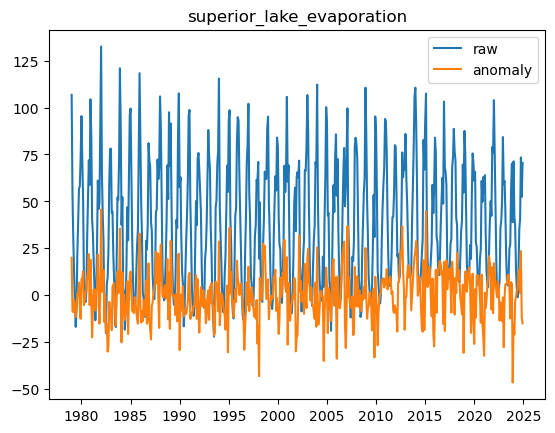

In [66]:
var = "superior_lake_evaporation"

plt.figure()
plt.plot(X[var], label="raw")
plt.plot(X_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

### Add Temporal Features and Reorder Predictors

This step adds temporal features to the predictor matrix, including `time`, `month_sin`, and `month_cos`. These variables help the model represent long-term temporal progression and smooth seasonal variability across months.

The feature columns are then reorganized into a consistent order for model training and inference. Optional current-state predictors, including SST and SWE, are only included if they were enabled in the user configuration.

In [67]:
# Add time, month_sin, and month_cos features
X_time = CFSTransformer(X_merged).add_time_features()

# Always include temporal features first
feature_column_order = [
    'time',
    'month_sin',
    'month_cos'
]

# Include SWE features only if enabled
if use_swe:
    feature_column_order += [
        'superior_swe',
        'michigan-huron_swe',
        'erie_swe',
        'ontario_swe'
    ]

# Include SST features only if enabled
if use_sst:
    feature_column_order += [
        'superior_sst',
        'michigan-huron_sst',
        'erie_sst',
        'ontario_sst'
    ]

# Add lead-time CFS predictor variables
feature_column_order += [
    f'{lake}_{surface_type}_{comp}_mo{m}'
    for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
    for surface_type in ['lake', 'land']
    for comp in ['precipitation', 'evaporation', 'air_temperature']
    for m in range(10)
]

# Keep only columns that exist in X_time.
# This makes the workflow robust if optional features are disabled.
feature_column_order = [
    col for col in feature_column_order
    if col in X_time.columns
]

X_reorg = X_time[feature_column_order]

In [68]:
print(X_reorg)

                time     month_sin     month_cos  \
date                                               
1979-01-01 -1.728864  5.000000e-01  8.660254e-01   
1979-02-01 -1.722484  8.660254e-01  5.000000e-01   
1979-03-01 -1.716105  1.000000e+00  6.123234e-17   
1979-04-01 -1.709725  8.660254e-01 -5.000000e-01   
1979-05-01 -1.703346  5.000000e-01 -8.660254e-01   
...              ...           ...           ...   
2023-11-01  1.703346 -5.000000e-01  8.660254e-01   
2023-12-01  1.709725 -2.449294e-16  1.000000e+00   
2024-01-01  1.716105  5.000000e-01  8.660254e-01   
2024-02-01  1.722484  8.660254e-01  5.000000e-01   
2024-03-01  1.728864  1.000000e+00  6.123234e-17   

            superior_lake_precipitation_mo0  superior_lake_precipitation_mo1  \
date                                                                           
1979-01-01                        -5.534390                        15.798211   
1979-02-01                        15.798211                        68.074182   
197

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [69]:
# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

targets_shifted = CFSTransformer(targets).shift_variables(lag=0, lead=12)

### Remove the Seasonal Cycle from Target Variables

This step calculates the climatological seasonal cycle for the target variables using the training-period data only in order to avoid data leakage into the validation and forecast periods.

Monthly climatological means are calculated for each target variable and used to define the expected seasonal baseline conditions. The fitted climatology is then removed from the full target dataset to generate anomaly-based target variables (`targets_anom`).

The resulting climatology artifacts are saved to disk so the identical seasonal baseline can be applied consistently during operational forecasting and inverse transformation back to native units.

In [70]:
# 1) Fit monthly climatology on TRAIN ONLY (avoid leakage)
scp_y = SeasonalCycleProcessor().fit(
    targets,
    var_list=list(targets.columns),          # explicit is good here
    baseline_time=train_slice,
    baseline_definition={
        "train_start": train_start_date,
        "train_end": train_end_date,
        "note": "targets climatology fit on training period only"
    },
)

# 2) Transform full targets to anomalies
targets_anom = scp_y.transform(targets)

# Save artifact so forecast notebook can load the same baseline
paths = scp_y.save(input_dir + "input/climatology/targets")

       superior_target_evaporation  superior_target_precipitation  \
month                                                               
1                       103.922230                      51.755641   
2                        58.874766                      34.955128   
3                        42.587684                      42.244615   
4                        16.323566                      56.792821   
5                         2.504305                      71.029231   
6                        -3.007454                      81.873846   
7                        -0.722389                      77.578205   
8                        15.746432                      75.816667   
9                        51.351828                      82.584103   
10                       73.727126                      76.761538   
11                       99.853890                      62.144615   
12                      118.657172                      56.633333   

       superior_target_runoff  su

### Verify Native and Anomaly Target Data

This diagnostic plot compares the original target variable time series with its anomaly-transformed counterpart after seasonal cycle removal.

The raw target series (`targets`) represents the native hydrologic values, while the anomaly series (`targets_anom`) represents departures from the climatological monthly mean calculated from the training period. This visualization serves as a quality-control check to confirm that the seasonal cycle was successfully removed while preserving interannual variability and anomalous hydrologic events.

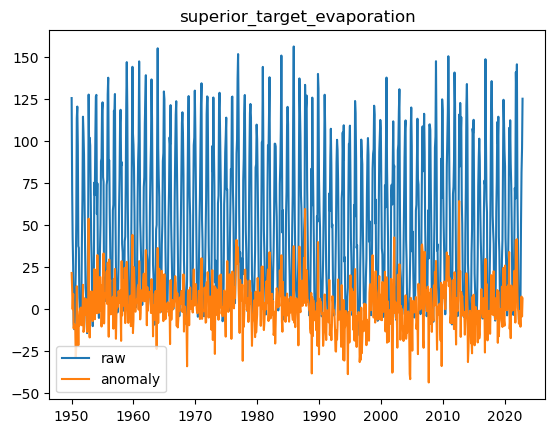

In [71]:
import matplotlib.pyplot as plt

var = "superior_target_evaporation"
plt.figure()
plt.plot(targets[var], label="raw")
plt.plot(targets_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

### Create Lead-Time Target Variables

This step converts the anomaly-based target variables into lead-time forecast targets spanning 12 months ahead.

Target variables are shifted to create forecast lead times from `mo0` through `mo11`, representing the full 12-month prediction horizon for each lake and hydrologic component. The resulting target columns are then reorganized into a consistent ordering to ensure compatibility with machine learning training, validation, and forecasting workflows.


In [72]:
# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets_anom).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [73]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_reorg.align(targets_reorg, join='inner', axis=0)
print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 243
Number of Targets: 192


## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [74]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


In [75]:
# Define the scaler we want to use
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Standardize the data
# This will scale the features and targets between 0 and 1
# It is important to fit the scaler on the training data and then transform both train and test data
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Save the scalers to use later during the prediction phase
joblib.dump(x_scaler, input_dir + 'input/scalers/x_scaler_anom.joblib')
joblib.dump(y_scaler, input_dir + 'input/scalers/y_scaler_anom.joblib')

['/Users/ljob/Desktop/cnbs-predictor/data/input/scalers/y_scaler_anom.joblib']

## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

(The function below should be added to the data processor)

In [76]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

#kernel = 1.0 * Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1e-10, 1e3)) \
#         * RationalQuadratic(alpha=0.0001, length_scale=.01, length_scale_bounds=(1e-10, 1e3))

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

# Set up the model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr, input_dir + 'input/models/GP_trained_model_anom.joblib')

# Predictions
y_pred_GP, sigma = gpr.predict(X_test_scaled, return_std=True)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_GP)

print(f"R² Score: {r2:.4f}")
# Optimized kernel after training
print("Optimized Kernel:", gpr.kernel_)

# Kernel hyperparameters
print("Kernel Hyperparameters:", gpr.kernel_.theta)

R² Score: 0.3200
Optimized Kernel: 3.63**2 * Matern(length_scale=107, nu=1.5) * RationalQuadratic(alpha=0.000621, length_scale=1e-05)
Kernel Hyperparameters: [  2.57582192   4.66901661  -7.38370945 -11.51292546]


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [77]:
def unscale_to_df(y_std, scaler, index, columns):
    return pd.DataFrame(scaler.inverse_transform(y_std), index=index, columns=columns)

def r2_flat(a, b):
    return r2_score(a.to_numpy().ravel(), b.to_numpy().ravel())

# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_GP,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.2776862536650879
R² (absolute, reconstructed): 0.733900628115352
R² (absolute, climatology-only): 0.6312143325986058


In [78]:
import xgboost as xgb

# Create the XGBoost regressor 
xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # for regression
)

# Train the model
xgb.fit(X_train_scaled, y_train_scaled)

# Predict on the test set
y_pred_XGB = xgb.predict(X_test_scaled)

# Save the trained model
joblib.dump(xgb, input_dir + 'input/models/XGB_trained_model_anom.joblib')

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_XGB)

print(f"R² Score: {r2:.4f}")

R² Score: 0.2725


In [79]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_XGB,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.26609235285500954
R² (absolute, reconstructed): 0.7296294513048467
R² (absolute, climatology-only): 0.6312143325986058


In [80]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, input_dir + 'input/models/RF_trained_model_anom.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_RFR)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0779


In [81]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_RFR,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.12179623841744225
R² (absolute, reconstructed): 0.6764709649655483
R² (absolute, climatology-only): 0.6312143325986058


(468, 243) (468, 192)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0851 - mae: 0.8022 - val_loss: 1.1664 - val_mae: 0.8148
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9671 - mae: 0.7504 - val_loss: 1.1356 - val_mae: 0.8009
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9445 - mae: 0.7403 - val_loss: 1.1297 - val_mae: 0.7975
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9267 - mae: 0.7327 - val_loss: 1.1312 - val_mae: 0.7968
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9020 - mae: 0.7223 - val_loss: 1.1352 - val_mae: 0.7979
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8714 - mae: 0.7101 - val_loss: 1.1401 - val_mae: 0.7997
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8342 - mae: 0.6959 - val_loss: 1.1242 - val_mae: 0.7941
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7967 - mae: 0.6814 - val_loss: 1.1161 - val_mae: 0.7915
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

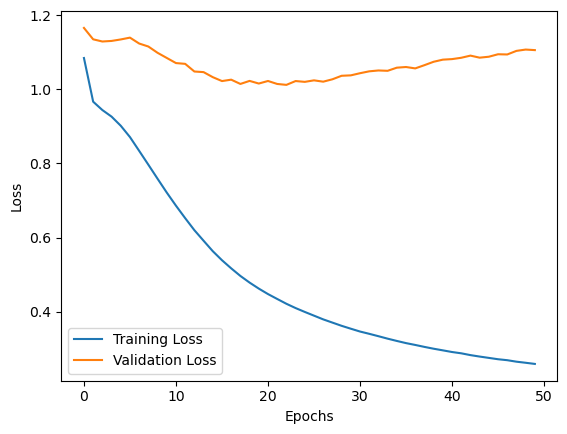

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
R² Score: -0.0948


In [82]:
## Neural Network ##

# Define the neural network architecture
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

print(X_train_scaled.shape, y_train_scaled.shape)
# Fit the model to the training data
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(nn_model, input_dir + 'input/models/NN_trained_model_anom.joblib')

# Predict on the test set
y_pred_NN = nn_model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_NN)

print(f"R² Score: {r2:.4f}")

In [83]:
def make_abs_df(y_pred, model_name):
    y_anom = unscale_to_df(
        y_pred,
        y_scaler,
        y_test.index,
        y_test.columns
    )

    y_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(
        y_anom,
        scp_y
    )

    # copy() defragments; assign() avoids repeated column insertion issues
    return y_abs.copy().assign(model=model_name)


y_gp_abs = make_abs_df(y_pred_GP,  "GP")
y_rf_abs = make_abs_df(y_pred_RFR, "RFR")
y_nn_abs = make_abs_df(y_pred_NN,  "NN")
y_xgb_abs = make_abs_df(y_pred_XGB, "XGB")

df_all = (
    pd.concat(
        [y_gp_abs, y_rf_abs, y_nn_abs, y_xgb_abs],
        axis=0
    )
    .reset_index()
    .rename(columns={"date": "cfs_run", "index": "cfs_run"})
)

In [84]:
# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)


In [85]:
# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['lake'] = split_cols[0].str.replace('_target', '', regex=False)
df_melted['variable'] = split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month (vectorized, better)
df_melted['cfs_run'] = pd.to_datetime(df_melted['cfs_run'])
df_melted['forecast_month'] = (
    df_melted['cfs_run'].dt.to_period('M') +
    df_melted['month_offset']
).astype(str)


In [86]:
df_melted_tmp = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot with BOTH lake + variable as columns
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns=['lake', 'variable'],
    values='value'
)

# Flatten MultiIndex columns → "lake_variable"
df_tidy.columns = [f"{lake}_{var}" for lake, var in df_tidy.columns]

df_tidy = df_tidy.reset_index()

# Step 5: Reorder columns
expected_vars = ["precipitation", "evaporation", "runoff", "nbs"]
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']

ordered_feature_cols = [
    f"{lake}_{var}"
    for lake in lakes
    for var in expected_vars
    if f"{lake}_{var}" in df_tidy.columns
]

cols = ["cfs_run", "forecast_month", "model"] + ordered_feature_cols

df_final = df_tidy[cols]

# Convert cfs_run back to YYYYMMDDHH format
df_final["cfs_run"] = pd.to_datetime(df_final["cfs_run"]).dt.strftime("%Y%m%d%H")

In [87]:
# Optionally save the test data
output_dir = os.path.join(input_dir, "output")
os.makedirs(output_dir, exist_ok=True)

df_final.to_csv(
    os.path.join(output_dir, "CNBS_test_anom.csv"),
    index=True
)

In [88]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_NN,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.019113897631735766
R² (absolute, reconstructed): 0.6245598683193534
R² (absolute, climatology-only): 0.6312143325986058


Calculate Skill Metrics on the Test Data Set

In [89]:
def compute_skill_metrics(
    model,
    y_true_std,
    y_pred_std,
    y_scaler,
    *,
    y_index,
    y_columns,
    seasonal_processor=None,
    by_lead=False,
):
    """
    Compute skill metrics for lead-wide targets in:
      (1) anomaly space
      (2) absolute reconstructed space (adds monthly climatology back; lead-aware)
      (3) absolute climatology-only baseline (lead-aware)

    Parameters
    ----------
    model : str
        Model name.

    y_true_std : np.ndarray
        True values in standardized space, shape (n_samples, n_targets).

    y_pred_std : np.ndarray
        Predicted values in standardized space, shape (n_samples, n_targets).

    y_scaler : sklearn-like scaler
        Must implement inverse_transform() mapping standardized -> anomaly units.

    y_index : pd.DatetimeIndex
        Index for the target rows (init dates).

    y_columns : list[str]
        Target column names, expected to include suffixes like '_mo0'..'_mo11'.

    seasonal_processor : SeasonalCycleProcessor, optional
        If provided, must contain `climatology` used to reconstruct absolute values.

    by_lead : bool
        If True, adds R² by lead month as columns: R²_mo0 ... R²_mo11
        (computed in each space where applicable).

    Returns
    -------
    pd.DataFrame
        One or more rows (one per Space) with metrics.
        Columns include: Model, Space, RMSE, R², Bias, Std Dev, CRPS (+ optional lead columns)
    """

    def to_df(y_std):
        return pd.DataFrame(
            y_scaler.inverse_transform(y_std),
            index=y_index,
            columns=y_columns
        )

    def flat_metrics(y_true_df, y_pred_df):
        yt = y_true_df.to_numpy().ravel()
        yp = y_pred_df.to_numpy().ravel()

        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)  # IMPORTANT: consistent space (not standardized)
        bias = np.mean(yp - yt)
        std_dev = np.std(yp - yt, ddof=1)
        crps = np.mean(crps_ensemble(yt, yp[:, None]))  # deterministic CRPS
        return rmse, r2, bias, std_dev, crps

    def r2_by_lead(y_true_df, y_pred_df):
        out = {}
        for lead in range(12):
            cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
            if not cols:
                continue
            out[f"R²_mo{lead}"] = r2_score(
                y_true_df[cols].to_numpy().ravel(),
                y_pred_df[cols].to_numpy().ravel()
            )
        return out

    rows = []

    # --- (1) anomaly space ---
    y_true_anom = to_df(y_true_std)
    y_pred_anom = to_df(y_pred_std)

    rmse, r2, bias, std_dev, crps = flat_metrics(y_true_anom, y_pred_anom)
    row = {
        "Model": model,
        "Space": "anomaly",
        "RMSE": round(rmse, 3),
        "R²": round(r2, 3),
        "Bias": round(bias, 3),
        "Std Dev": round(std_dev, 3),
        "CRPS": round(crps, 3),
    }
    if by_lead:
        row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_anom, y_pred_anom).items()})
    rows.append(row)

    # --- (2) absolute reconstructed + (3) climatology-only ---
    if seasonal_processor is not None:
        y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, seasonal_processor)
        y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_pred_abs)
        row = {
            "Model": model,
            "Space": "absolute_reconstructed",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_pred_abs).items()})
        rows.append(row)

        # climatology-only baseline: 0 anomalies + climatology
        y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_clim_abs)
        row = {
            "Model": model,
            "Space": "absolute_climatology_only",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_clim_abs).items()})
        rows.append(row)

    return pd.DataFrame(rows)

In [90]:
skill_GP = compute_skill_metrics(
    "Gaussian Process",
    y_test_scaled,
    y_pred_GP,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_RF = compute_skill_metrics(
    "Random Forest",
    y_test_scaled,
    y_pred_RFR,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_XGB = compute_skill_metrics(
    "XG Boost",
    y_test_scaled,
    y_pred_XGB,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_NN = compute_skill_metrics(
    "Neural Network",
    y_test_scaled,
    y_pred_NN,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

results_df = pd.concat([skill_GP, skill_RF, skill_NN, skill_XGB], ignore_index=True)

In [91]:
results_df

,Model,Space,RMSE,R²,Bias,Std Dev,CRPS,R²_mo0,R²_mo1,R²_mo2,R²_mo3,R²_mo4,R²_mo5,R²_mo6,R²_mo7,R²_mo8,R²_mo9,R²_mo10,R²_mo11
0,Gaussian Process,anomaly,38.345,0.278,2.464,38.268,22.844,0.329,0.382,0.346,0.339,0.311,0.326,0.343,0.301,0.398,0.429,-0.055,-0.125
1,Gaussian Process,absolute_reconstructed,38.345,0.734,2.464,38.268,22.844,0.753,0.773,0.767,0.769,0.749,0.747,0.753,0.738,0.776,0.787,0.604,0.581
2,Gaussian Process,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
3,Random Forest,anomaly,42.281,0.122,0.099,42.283,26.489,0.078,0.168,0.118,0.143,0.128,0.110,0.155,0.138,0.147,0.150,0.074,0.049
4,Random Forest,absolute_reconstructed,42.281,0.676,0.099,42.283,26.489,0.661,0.694,0.686,0.701,0.682,0.666,0.683,0.678,0.683,0.683,0.653,0.646
5,Random Forest,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
6,Neural Network,anomaly,45.547,-0.019,-3.200,45.437,28.289,0.150,0.075,0.044,0.005,0.011,0.015,0.058,0.048,0.045,0.061,-0.281,-0.472
7,Neural Network,absolute_reconstructed,45.547,0.625,-3.200,45.437,28.289,0.687,0.660,0.659,0.653,0.639,0.631,0.646,0.644,0.645,0.650,0.520,0.452
8,Neural Network,absolute_climatology_only,45.141,0.631,-1.462,45.120,28.005,0.631,0.632,0.644,0.650,0.635,0.624,0.624,0.625,0.628,0.627,0.625,0.628
9,XG Boost,anomaly,38.652,0.266,1.965,38.604,23.529,0.272,0.323,0.339,0.337,0.311,0.316,0.335,0.298,0.356,0.388,-0.028,-0.058


In [92]:
# start from results_df (the big table)
base = results_df[["Model", "Space", "RMSE", "R²", "Bias", "Std Dev", "CRPS"]].copy()

recon = base[base["Space"] == "absolute_reconstructed"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_abs", "RMSE": "RMSE_abs"}
)
anom = base[base["Space"] == "anomaly"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_anom", "RMSE": "RMSE_anom"}
)
clim = base[base["Space"] == "absolute_climatology_only"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_clim", "RMSE": "RMSE_clim"}
)

summary = (
    recon.merge(anom, on="Model")
         .merge(clim, on="Model")
         .assign(delta_R2=lambda d: d["R²_abs"] - d["R²_clim"])
         .sort_values("delta_R2", ascending=False)
         .reset_index(drop=True)
)

summary.style.format({
    "R²_abs": "{:.3f}", "R²_anom": "{:.3f}", "R²_clim": "{:.3f}", "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}", "RMSE_anom": "{:.2f}", "RMSE_clim": "{:.2f}",
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2
0,Gaussian Process,0.734,38.34,0.278,38.34,0.631,45.14,0.103
1,XG Boost,0.730,38.65,0.266,38.65,0.631,45.14,0.099
2,Random Forest,0.676,42.28,0.122,42.28,0.631,45.14,0.045
3,Neural Network,0.625,45.55,-0.019,45.55,0.631,45.14,-0.006


In [93]:
def plot_styled_table(df):
    fig, ax = plt.subplots(figsize=(1.8 * len(df.columns), 1 + 0.5 * len(df)))
    ax.axis('off')

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    ncols = len(df.columns)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(11)

        cell.set_height(0.12)

        # Wider model column
        if col == 0:
            cell.set_width(0.25)
        else:
            cell.set_width(0.75 / (ncols - 1))

    table.auto_set_font_size(False)

    plt.tight_layout()
    plt.show()

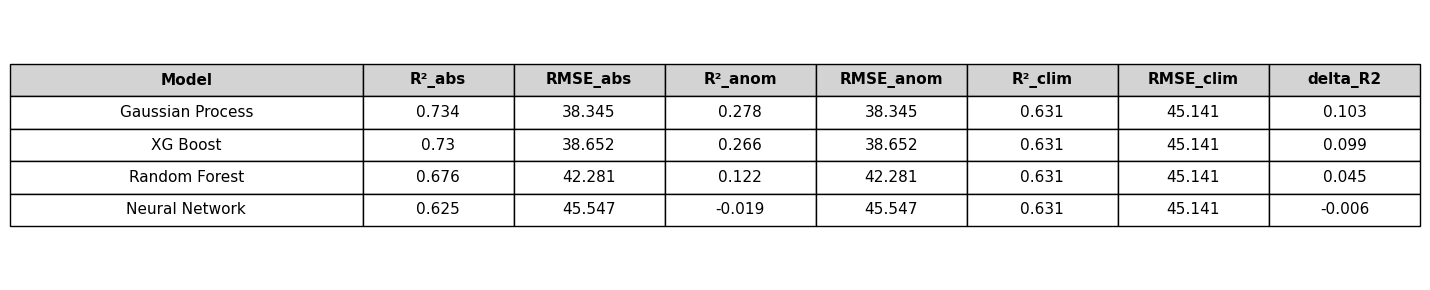

In [94]:
plot_styled_table(summary)

In [95]:
lead_cols = [c for c in results_df.columns if c.startswith("R²_mo")]

lead_skill = (
    results_df[results_df["Space"] == "anomaly"][["Model"] + lead_cols]
    .melt(id_vars="Model", var_name="lead", value_name="R²")
)

lead_skill["lead"] = lead_skill["lead"].str.replace("R²_mo", "").astype(int)
lead_skill = lead_skill.sort_values(["Model", "lead"])

#### Plot anomaly skill by lead month and method

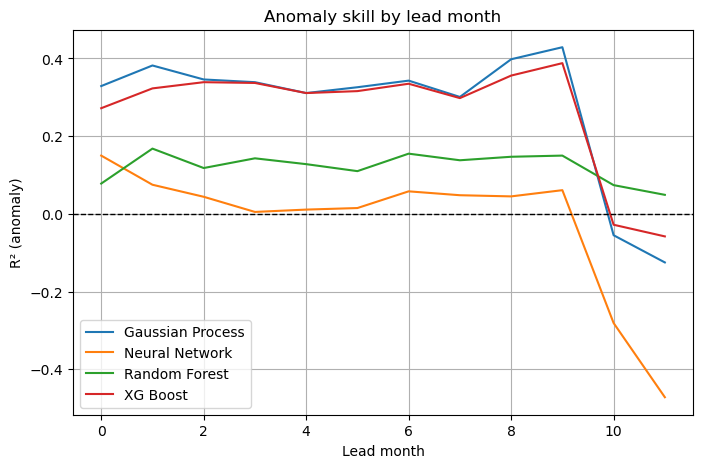

In [96]:
plt.figure(figsize=(8,5))
for model, g in lead_skill.groupby("Model"):
    plt.plot(g["lead"], g["R²"], label=model)

plt.axhline(0, linewidth=1, color='black', linestyle='--')
plt.xlabel("Lead month")
plt.ylabel("R² (anomaly)")
plt.title("Anomaly skill by lead month")
plt.legend()
plt.grid(True)
plt.show()

### Plot skill score relative to climatology 

Current setup below will just run this analysis for the last model to be tested, so the results don't reflect the "best" modeling efforts necessarily

In [97]:
summary = summary.assign(
    SkillScore=lambda d: 1 - d["RMSE_abs"] / d["RMSE_clim"]
)

summary.style.format({
    "R²_abs": "{:.3f}",
    "R²_clim": "{:.3f}",
    "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}",
    "RMSE_clim": "{:.2f}",
    "SkillScore": "{:.3f}"
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2,SkillScore
0,Gaussian Process,0.734,38.34,0.278000,38.345000,0.631,45.14,0.103,0.151
1,XG Boost,0.730,38.65,0.266000,38.652000,0.631,45.14,0.099,0.144
2,Random Forest,0.676,42.28,0.122000,42.281000,0.631,45.14,0.045,0.063
3,Neural Network,0.625,45.55,-0.019000,45.547000,0.631,45.14,-0.006,-0.009


In [98]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def rmse_by_lead(y_true_df, y_pred_df):
    results = {}
    for lead in range(12):
        cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
        if not cols:
            continue
        
        yt = y_true_df[cols].to_numpy().ravel()
        yp = y_pred_df[cols].to_numpy().ravel()
        
        results[lead] = rmse(yt, yp)
        
    return results

In [99]:
rmse_model = rmse_by_lead(y_true_abs, y_pred_abs)
rmse_clim  = rmse_by_lead(y_true_abs, y_clim_abs)

skill_by_lead = {
    lead: 1 - rmse_model[lead] / rmse_clim[lead]
    for lead in rmse_model
}

skill_by_lead_df = (
    pd.DataFrame({
        "lead": list(skill_by_lead.keys()),
        "SkillScore": list(skill_by_lead.values())
    })
    .sort_values("lead")
)

skill_by_lead_df

,lead,SkillScore
0,0,0.078843
1,1,0.039172
2,2,0.022627
3,3,0.003551
4,4,0.006567
5,5,0.008326
6,6,0.030041
7,7,0.025032
8,8,0.023334
9,9,0.031050


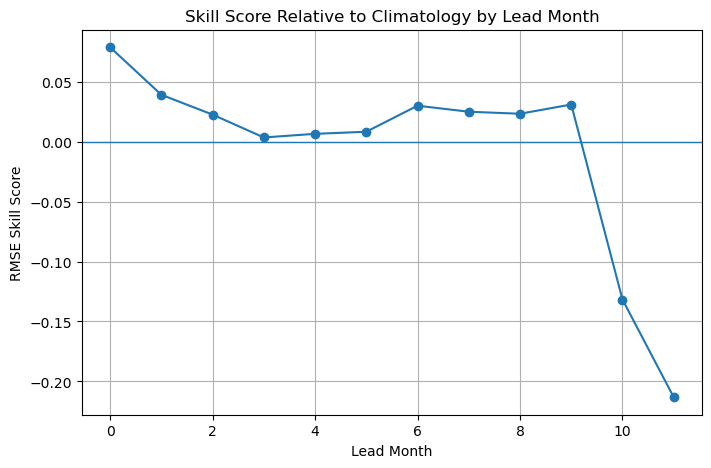

In [100]:
plt.figure(figsize=(8,5))
plt.plot(skill_by_lead_df["lead"], skill_by_lead_df["SkillScore"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Lead Month")
plt.ylabel("RMSE Skill Score")
plt.title("Skill Score Relative to Climatology by Lead Month")
plt.grid(True)
plt.show()

In [101]:
targets

,superior_target_evaporation,superior_target_precipitation,superior_target_runoff,superior_target_nbs,michigan-huron_target_evaporation,michigan-huron_target_precipitation,michigan-huron_target_runoff,michigan-huron_target_nbs,erie_target_evaporation,erie_target_precipitation,erie_target_runoff,erie_target_nbs,ontario_target_evaporation,ontario_target_precipitation,ontario_target_runoff,ontario_target_nbs
date,,,,,,,,,,,,,,,,
1950-01-01,125.357918,88.75,33.2,14.026862,95.709892,91.03,104.7,94.677343,38.810083,166.00,238.30,550.186890,75.883804,111.8,271.8,375.028505
1950-02-01,70.413371,36.98,25.5,-8.961299,59.667369,64.88,65.8,57.923217,40.703714,94.80,136.20,258.878682,77.272852,88.8,147.1,188.013699
1950-03-01,42.505142,62.08,31.0,49.607194,36.461632,77.05,81.9,124.142145,26.439582,97.00,162.60,427.763105,43.856645,71.4,196.6,323.419078
1950-04-01,25.310708,89.29,48.1,142.365472,23.005784,84.70,125.2,200.438931,16.345690,101.30,161.40,367.968263,17.753245,60.1,283.2,529.412835
1950-05-01,-8.965747,147.60,115.5,340.750102,0.003105,55.79,110.9,130.425081,10.834650,47.30,68.10,115.222385,2.194818,52.9,117.2,182.353310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,5.267900,73.93,36.0,83.476933,41.785871,84.30,33.5,38.130921,112.690526,101.69,20.42,24.484757,69.512130,84.0,40.7,22.364085
2022-09-01,50.655000,104.23,36.5,83.763871,76.020764,71.23,32.2,-21.176080,161.345409,88.97,25.36,-90.598246,88.009890,65.4,53.8,-39.955686
2022-10-01,81.158000,63.07,41.3,13.684743,87.836585,72.61,37.1,-2.383183,177.551294,50.74,17.61,-154.109940,84.626460,32.1,45.6,-46.448485


# Integrated NBS skill

Trying out 1, 3, and 6 month integrated NBS skill

In [102]:
def compute_integrated_skill(
    y_true_df,
    y_pred_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute skill on integrated (rolling-sum) lead windows.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Reconstructed absolute true values (with _mo{k} columns)

    y_pred_df : pd.DataFrame
        Reconstructed absolute predicted values

    variable : str
        Base variable name (e.g., 'superior_target_nbs')

    window : int
        Integration window (1, 3, 6 months)

    Returns
    -------
    float
        R² for integrated values
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values

    # rolling integration across lead axis
    integrated_true = []
    integrated_pred = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(
            y_true_vals[:, start:start+window].sum(axis=1)
        )
        integrated_pred.append(
            y_pred_vals[:, start:start+window].sum(axis=1)
        )

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)

    return r2_score(integrated_true, integrated_pred)

In [103]:
r2_1m = compute_integrated_skill(y_true_abs, y_pred_abs, window=1)
r2_3m = compute_integrated_skill(y_true_abs, y_pred_abs, window=3)
r2_6m = compute_integrated_skill(y_true_abs, y_pred_abs, window=6)

print("1-month:", r2_1m)
print("3-month:", r2_3m)
print("6-month:", r2_6m)

1-month: 0.596363615571113
3-month: 0.7064567370540413
6-month: 0.5870103119733664


In [104]:
def compute_integrated_metrics(
    y_true_df,
    y_pred_df,
    y_clim_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute integrated metrics for model and climatology baseline.

    Returns:
        dict with:
            r2_model
            r2_climatology
            skill_score
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values
    y_clim_vals = y_clim_df[lead_cols].values

    integrated_true = []
    integrated_pred = []
    integrated_clim = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(y_true_vals[:, start:start+window].sum(axis=1))
        integrated_pred.append(y_pred_vals[:, start:start+window].sum(axis=1))
        integrated_clim.append(y_clim_vals[:, start:start+window].sum(axis=1))

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)
    integrated_clim = np.concatenate(integrated_clim)

    r2_model = r2_score(integrated_true, integrated_pred)
    r2_clim = r2_score(integrated_true, integrated_clim)

    mse_model = mean_squared_error(integrated_true, integrated_pred)
    mse_clim = mean_squared_error(integrated_true, integrated_clim)

    skill = 1 - (mse_model / mse_clim)

    return {
        "R2_model": r2_model,
        "R2_climatology": r2_clim,
        "Skill_vs_climatology": skill
    }

In [105]:
for w in [1, 3, 6]:
    metrics = compute_integrated_metrics(
        y_true_abs,
        y_pred_abs,
        y_clim_abs,
        variable="superior_target_nbs",
        window=w
    )
    print(f"\n{w}-month integration")
    print(metrics)


1-month integration
{'R2_model': 0.596363615571113, 'R2_climatology': 0.5996130134252748, 'Skill_vs_climatology': -0.008115643023166585}

3-month integration
{'R2_model': 0.7064567370540413, 'R2_climatology': 0.7099203553596614, 'Skill_vs_climatology': -0.011940232172838128}

6-month integration
{'R2_model': 0.5870103119733664, 'R2_climatology': 0.6068860640728388, 'Skill_vs_climatology': -0.050559774871871355}


# Exploring integrated NBS Options

In [106]:
def summarize_integrated_skill(
    y_true_abs,
    y_clim_abs,
    model_predictions,
    variable="superior_target_nbs",
    windows=(1, 3, 6)
):
    """
    Parameters
    ----------
    model_predictions : dict
        {"Model Name": y_pred_abs_df}
    """

    rows = []

    for model_name, y_pred_abs in model_predictions.items():
        for w in windows:

            metrics = compute_integrated_metrics(
                y_true_abs,
                y_pred_abs,
                y_clim_abs,
                variable=variable,
                window=w
            )

            rows.append({
                "Model": model_name,
                "Window (months)": w,
                "R2_model": round(metrics["R2_model"], 3),
                "R2_climatology": round(metrics["R2_climatology"], 3),
                "Skill_vs_climatology": round(metrics["Skill_vs_climatology"], 3)
            })

    return pd.DataFrame(rows)

In [107]:
def build_eval_frames(y_test_scaled, y_pred_scaled, y_scaler, y_index, y_columns, scp_y):
    """
    Build evaluation DataFrames in three spaces:
      - anomaly (units after inverse StandardScaler)
      - absolute reconstructed (lead-aware climatology added back)
      - absolute climatology-only baseline (lead-aware)

    Returns
    -------
    dict with keys: 'anom', 'abs', 'clim_abs'
      each value is a pd.DataFrame shaped like (n_times, n_targets)
    """
    # 1) standardized -> anomaly units
    y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_index, y_columns)
    y_pred_anom = unscale_to_df(y_pred_scaled, y_scaler, y_index, y_columns)

    # 2) anomaly -> absolute (lead-aware)
    y_true_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom, scp_y)
    y_pred_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_pred_anom, scp_y)

    # 3) climatology-only baseline
    y_clim_abs = SeasonalCycleProcessor().add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)

    return {
        "true_anom": y_true_anom,
        "pred_anom": y_pred_anom,
        "true_abs": y_true_abs,
        "pred_abs": y_pred_abs,
        "clim_abs": y_clim_abs,
    }

In [108]:
frames_GP = build_eval_frames(y_test_scaled, y_pred_GP,  y_scaler, y_test.index, y_test.columns, scp_y)
frames_RF = build_eval_frames(y_test_scaled, y_pred_RFR, y_scaler, y_test.index, y_test.columns, scp_y)
frames_XGB = build_eval_frames(y_test_scaled, y_pred_XGB, y_scaler, y_test.index, y_test.columns, scp_y)
frames_NN = build_eval_frames(y_test_scaled, y_pred_NN,  y_scaler, y_test.index, y_test.columns, scp_y)

In [109]:
def integrated_summary_for_models(frames_by_model, variable, windows=(1,3,6)):
    rows = []
    for model_name, fr in frames_by_model.items():
        for w in windows:
            m = compute_integrated_metrics(
                fr["true_abs"],
                fr["pred_abs"],
                fr["clim_abs"],
                variable=variable,
                window=w
            )
            rows.append({
                "Model": model_name,
                "Window": w,
                "R2_model": round(m["R2_model"], 3),
                "R2_clim": round(m["R2_climatology"], 3),
                "Skill": round(m["Skill_vs_climatology"], 3),
            })
    return pd.DataFrame(rows)

frames_by_model = {
    "Gaussian Process": frames_GP,
    "Random Forest": frames_RF,
    "XGBoost": frames_XGB,
    "Neural Network": frames_NN,
}

integrated_df = integrated_summary_for_models(
    frames_by_model,
    variable="superior_target_nbs",
    windows=(1,3,6)
)

integrated_df

,Model,Window,R2_model,R2_clim,Skill
0,Gaussian Process,1,0.793,0.600,0.484
1,Gaussian Process,3,0.885,0.710,0.603
2,Gaussian Process,6,0.868,0.607,0.665
3,Random Forest,1,0.636,0.600,0.090
4,Random Forest,3,0.759,0.710,0.170
5,Random Forest,6,0.708,0.607,0.257
6,XGBoost,1,0.752,0.600,0.380
7,XGBoost,3,0.840,0.710,0.448
8,XGBoost,6,0.780,0.607,0.442
9,Neural Network,1,0.596,0.600,-0.008


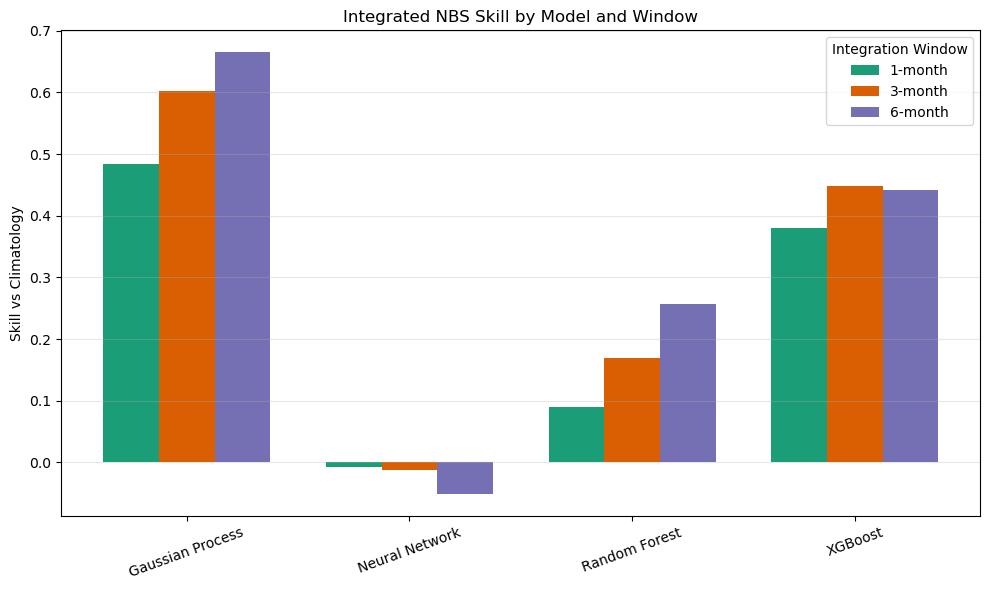

In [110]:
skill_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="Skill"
).sort_index()

models = skill_pivot.index
windows = skill_pivot.columns

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # Dark2

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        skill_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Skill vs Climatology")
ax.set_title("Integrated NBS Skill by Model and Window")
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

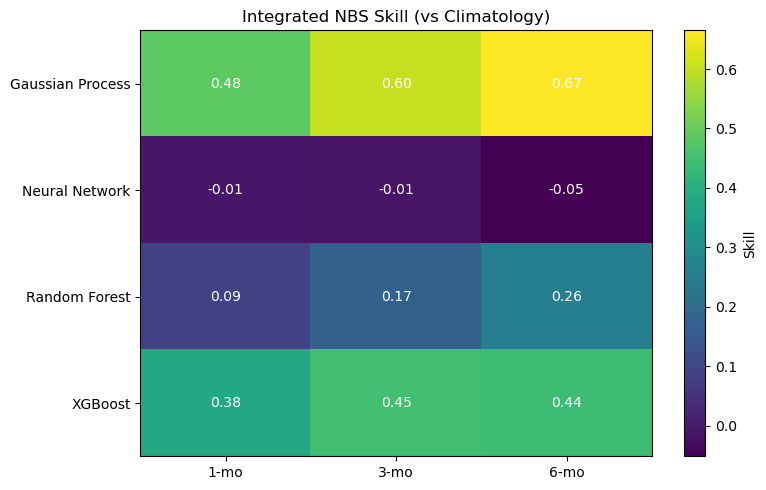

In [111]:
fig, ax = plt.subplots(figsize=(8, 5))

c = ax.imshow(skill_pivot.values, aspect='auto')

ax.set_xticks(range(len(windows)))
ax.set_xticklabels([f"{w}-mo" for w in windows])
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)

ax.set_title("Integrated NBS Skill (vs Climatology)")
plt.colorbar(c, label="Skill")

# Annotate cells
for i in range(len(models)):
    for j in range(len(windows)):
        ax.text(j, i, f"{skill_pivot.values[i, j]:.2f}",
                ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

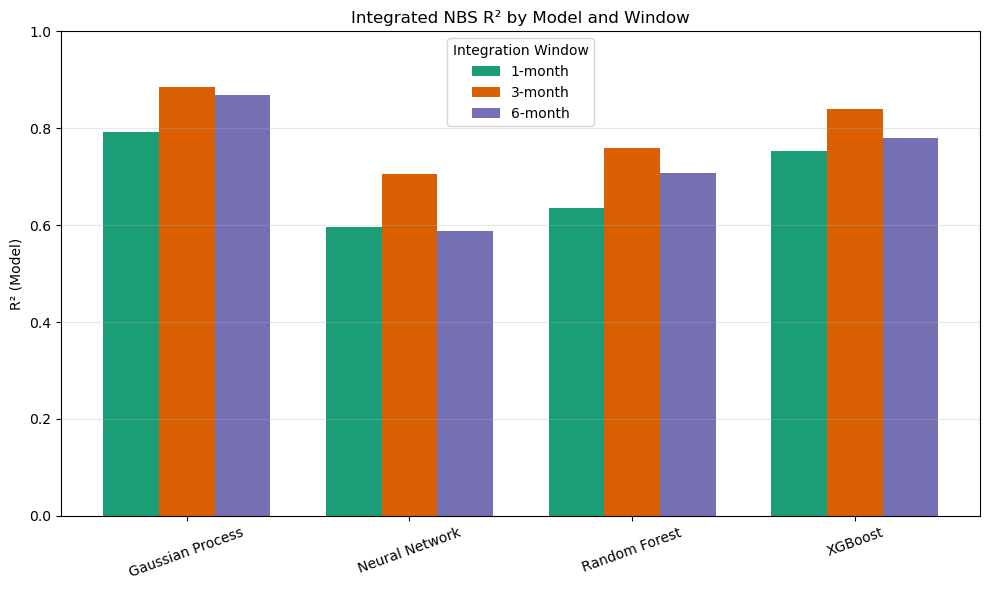

In [112]:
import matplotlib.pyplot as plt
import numpy as np

r2_model_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_model"
).sort_index()

models = r2_model_pivot.index
windows = r2_model_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_model_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Model)")
ax.set_title("Integrated NBS R² by Model and Window")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

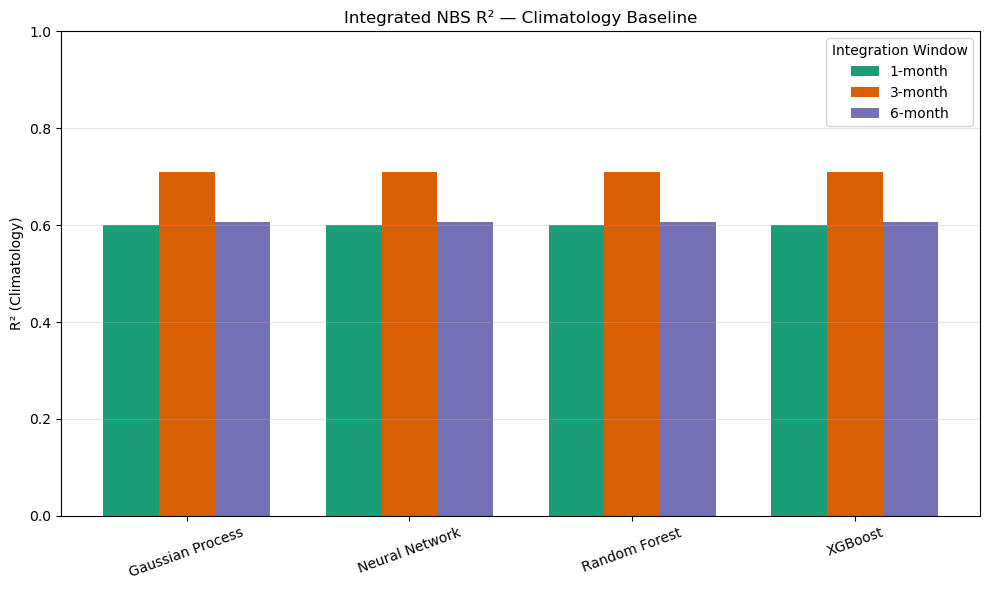

In [113]:
r2_clim_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_clim"
).sort_index()

models = r2_clim_pivot.index
windows = r2_clim_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_clim_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Climatology)")
ax.set_title("Integrated NBS R² — Climatology Baseline")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

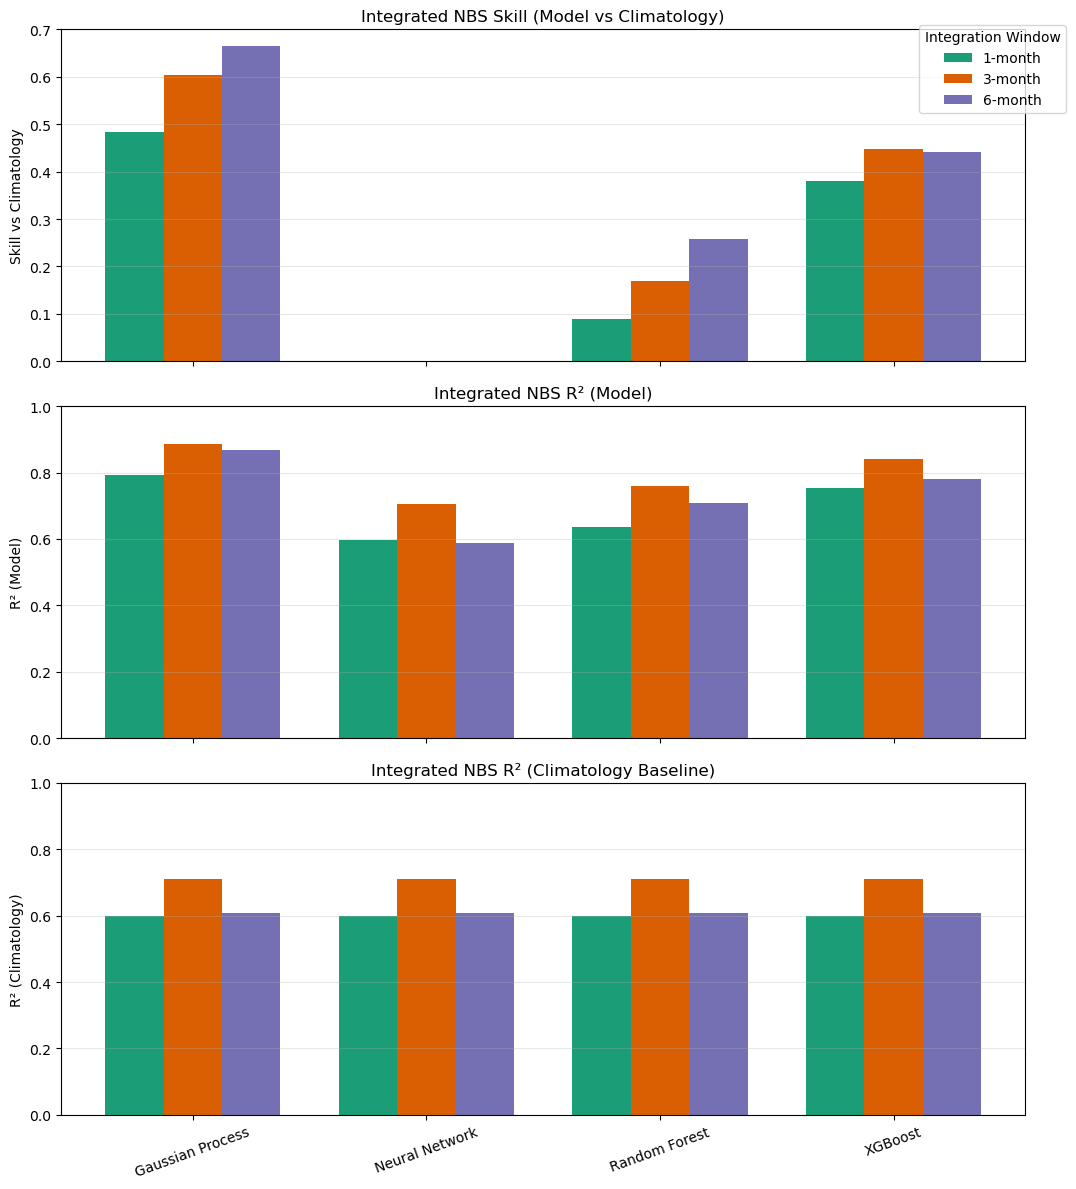

In [114]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # ColorBrewer Dark2 (colorblind-friendly)

def plot_grouped_bars(ax, pivot_df, ylabel, title, colors, ylim=(0, 1)):
    models = pivot_df.index
    windows = pivot_df.columns
    x = np.arange(len(models))
    width = 0.25

    for i, w in enumerate(windows):
        ax.bar(
            x + i*width - width,
            pivot_df[w].values,
            width,
            label=f"{w}-month",
            color=colors[i]
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20)

# Pivot tables
skill_pivot = integrated_df.pivot(index="Model", columns="Window", values="Skill").sort_index()
r2_model_pivot = integrated_df.pivot(index="Model", columns="Window", values="R2_model").sort_index()
r2_clim_pivot  = integrated_df.pivot(index="Model", columns="Window", values="R2_clim").sort_index()

# Create stacked figure
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 12), sharex=True)

plot_grouped_bars(
    axes[0], skill_pivot,
    ylabel="Skill vs Climatology",
    title="Integrated NBS Skill (Model vs Climatology)",
    colors=colors,
    ylim=(0, 0.7)  # skill is usually within [-inf, 1], but your range is positive and < 0.7
)

plot_grouped_bars(
    axes[1], r2_model_pivot,
    ylabel="R² (Model)",
    title="Integrated NBS R² (Model)",
    colors=colors,
    ylim=(0, 1)
)

plot_grouped_bars(
    axes[2], r2_clim_pivot,
    ylabel="R² (Climatology)",
    title="Integrated NBS R² (Climatology Baseline)",
    colors=colors,
    ylim=(0, 1)
)

# Put one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Integration Window", loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space for legend
plt.show()